In [1]:
# Setup imports & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
df = pd.read_csv('data/raw_transactions.csv', na_values=['Nan', ''])


# Section 13: 50 Senior Pandas Interview Questions & Interactive Solutions: Beginner Guide

### 📌 Overview
Master **Section 13: 50 Senior Pandas Interview Questions & Interactive Solutions: Beginner Guide** with concise, zero-fluff bullet points and executable code on real Fintech records ([raw_transactions.csv](file:///data/raw_transactions.csv)).

### 📚 Key Concepts Covered in this Notebook:
- **Core Foundations**: Master the core concepts and mechanics in simple terms.
- **Practical Application**: Step-by-step code execution on real transaction records.
- **Best Practices & Gotchas**: Practical tips to write clean, fast, and bug-free code.


### 🔍 Scenario: Q1: How do you perform a deep memory profile check on our transactions dataset, showing memory in MB for string columns?
- **Objective:** Q1: How do you perform a deep memory profile check on our transactions dataset, showing memory in MB for string columns?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [2]:
# Solution:
mem_bytes = df.memory_usage(deep=True)
for col in df.columns:
    print(f"Col '{col}': {mem_bytes[col] / 1e6:.4f} MB")

Col 'transaction_id': 0.8550 MB
Col 'customer_id': 0.8250 MB
Col 'merchant_id': 0.8100 MB
Col 'transaction_amount': 0.1200 MB
Col 'card_type': 0.8326 MB
Col 'transaction_status': 0.8477 MB
Col 'device_type': 0.8062 MB
Col 'account_age_months': 0.1200 MB
Col 'transaction_date': 0.9150 MB
Col 'region': 0.8030 MB
Col 'is_fraud': 0.1200 MB


### 🔍 Scenario: Q2: How do you downcast the numeric type of account_age_months to save memory using pd.to_numeric()?
- **Objective:** Q2: How do you downcast the numeric type of account_age_months to save memory using pd.to_numeric()?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [3]:
# Solution:
before_type = df['account_age_months'].dtype
df['account_age_months'] = pd.to_numeric(df['account_age_months'], downcast='unsigned')
after_type = df['account_age_months'].dtype
print(f"Type changed from {before_type} to {after_type}")

Type changed from int64 to uint8


### 🔍 Scenario: Q3: How do you convert the geographical 'region' column into a categorical type and check the compression ratio?
- **Objective:** Q3: How do you convert the geographical 'region' column into a categorical type and check the compression ratio?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [4]:
before_size = df['region'].memory_usage(deep=True)
# Solution:
df_optimized = df.copy()
df_optimized['region'] = df_optimized['region'].astype('category')
after_size = df_optimized['region'].memory_usage(deep=True)
print(f"Before: {before_size} bytes, After: {after_size} bytes")
print(f"Savings: {(1 - after_size/before_size)*100:.2f}%")

Before: 803144 bytes, After: 16082 bytes
Savings: 98.00%


### 🔍 Scenario: Q4: How do you stream/process chunks of data/raw_transactions.csv to compute the sum of transaction_amount without loading it fully into memory?
- **Objective:** Q4: How do you stream/process chunks of data/raw_transactions.csv to compute the sum of transaction_amount without loading it fully into memory?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [5]:
# Solution:
total_sum = 0
for chunk in pd.read_csv('data/raw_transactions.csv', chunksize=2000):
    total_sum += pd.to_numeric(chunk['transaction_amount'], errors='coerce').sum()
print("Total sum of transaction_amount via chunks:", total_sum)

Total sum of transaction_amount via chunks: 14326935.5


### 🔍 Scenario: Q5: Z-Score normalization: How do you subtract the group region mean and divide by group region std within groupby without merging?
- **Objective:** Q5: Z-Score normalization: How do you subtract the group region mean and divide by group region std within groupby without merging?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [6]:
# Solution:
grp_mean = df.groupby('region')['transaction_amount'].transform('mean')
grp_std = df.groupby('region')['transaction_amount'].transform('std')
df['amount_z_score'] = (df['transaction_amount'] - grp_mean) / grp_std
print(df[['region', 'transaction_amount', 'amount_z_score']].head(5))

  region  transaction_amount  amount_z_score
0  North              607.78       -0.679638
1   West             1819.11        1.401030
2   East               64.08       -1.622911
3   East             1025.73        0.054112
4  North              772.74       -0.395444


### 🔍 Scenario: Q6: How do you filter out entire regions that have an aggregate transaction volume below a threshold (e.g. 100,000)?
- **Objective:** Q6: How do you filter out entire regions that have an aggregate transaction volume below a threshold (e.g. 100,000)?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [7]:
# Solution:
result = df.groupby('region').filter(lambda g: g['transaction_amount'].sum() >= 100000)
print("Remaining regions:", result['region'].unique())

Remaining regions: ['North' 'West' 'East' 'South']


### 🔍 Scenario: Q7: How do you retrieve the top 3 highest-value transactions for each region using a custom apply?
- **Objective:** Q7: How do you retrieve the top 3 highest-value transactions for each region using a custom apply?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [8]:
# Solution:
result = df.groupby('region', group_keys=False).apply(lambda g: g.nlargest(3, 'transaction_amount'))
print(result[['region', 'transaction_id', 'transaction_amount']])

        region transaction_id  transaction_amount
10118    East        TX112849             1913.72
12230    East        TX110923             1882.23
9912     East        TX112042             1871.15
1742    North        TX101298             1969.61
155     North        TX109032             1938.18
26      North        TX109810             1916.91
9008    South        TX114444             1956.59
13336   South        TX103634             1939.96
11908   South        TX110967             1937.53
5502     West        TX113712             1994.40
14471    West        TX101474             1962.62
4966     West        TX100336             1952.96
102       East       TX113287             1999.41
5365      East       TX109638             1999.18
7973      East       TX102054             1998.84
1413     North       TX110393             1999.52
882      North       TX107277             1999.28
3099     North       TX113444             1998.96
11115    South       TX101707             1999.85


C:\Users\DELL\AppData\Local\Temp\ipykernel_23420\1441121769.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('region', group_keys=False).apply(lambda g: g.nlargest(3, 'transaction_amount'))


### 🔍 Scenario: Q8: How do you compute a 7-day rolling average of transaction amounts after setting transaction_date as index?
- **Objective:** Q8: How do you compute a 7-day rolling average of transaction amounts after setting transaction_date as index?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [9]:
df_roll = df.copy()
df_roll['transaction_date'] = pd.to_datetime(df_roll['transaction_date'], format='mixed')
df_roll = df_roll.set_index('transaction_date').sort_index()
# Solution:
rolling_avgs = df_roll['transaction_amount'].rolling('7D').mean()
print(rolling_avgs.head(15))

transaction_date
2025-01-01     196.470000
2025-01-01     360.495000
2025-01-01     884.693333
2025-01-01     963.582500
2025-01-01     836.400000
2025-01-01     937.296667
2025-01-01     957.977143
2025-01-01    1070.596250
2025-01-01     986.884444
2025-01-01    1043.976000
2025-01-01    1032.091818
2025-01-01    1097.064167
2025-01-01    1059.104615
2025-01-01    1001.918571
2025-01-01    1012.360667
Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q9: How do you compute the expanding standard deviation of transaction amounts chronologically?
- **Objective:** Q9: How do you compute the expanding standard deviation of transaction amounts chronologically?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [10]:
df_exp = df.copy()
df_exp['transaction_date'] = pd.to_datetime(df_exp['transaction_date'], format='mixed')
df_exp = df_exp.sort_values('transaction_date')
# Solution:
expanding_std = df_exp['transaction_amount'].expanding().std()
print(expanding_std.head(10))

4581            NaN
12074    231.966380
5526     922.635290
3946     769.673906
6697     724.689853
6459     693.701038
5574     635.618898
10442    669.148696
10099    674.432338
1854     660.994364
Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q10: How do you smooth out transaction trends using Exponentially Weighted Moving Average (EWMA) with span=30?
- **Objective:** Q10: How do you smooth out transaction trends using Exponentially Weighted Moving Average (EWMA) with span=30?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [11]:
df_ewm = df.copy()
df_ewm['transaction_date'] = pd.to_datetime(df_ewm['transaction_date'], format='mixed')
df_ewm = df_ewm.sort_values('transaction_date')
# Solution:
ewma_vals = df_ewm['transaction_amount'].ewm(span=30).mean()
print(ewma_vals.head(10))

4581      196.470000
12074     365.962500
5526      923.537297
3946      999.781731
6697      846.860039
6459      963.246758
5574      983.796282
10442    1120.348577
10099    1005.534729
1854     1078.740618
Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q11: How do you calculate the month-over-month percentage change in total transaction amounts?
- **Objective:** Q11: How do you calculate the month-over-month percentage change in total transaction amounts?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [12]:
df_time = df.copy()
df_time['transaction_date'] = pd.to_datetime(df_time['transaction_date'], format='mixed')
df_time = df_time.set_index('transaction_date').sort_index()
# Solution:
monthly_totals = df_time['transaction_amount'].resample('ME').sum()
pct_changes = monthly_totals.pct_change() * 100
print(pct_changes.head(10))

transaction_date
2025-01-31         NaN
2025-02-28   -6.059815
2025-03-31    3.972537
2025-04-30    4.050458
2025-05-31    5.175731
2025-06-30   -7.067238
2025-07-31    2.753916
2025-08-31    0.716296
2025-09-30   -4.334506
2025-10-31   -4.215296
Freq: ME, Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q12: How do you shift the transaction_amount column by 1 entry to find the previous transaction's amount for each customer?
- **Objective:** Q12: How do you shift the transaction_amount column by 1 entry to find the previous transaction's amount for each customer?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [13]:
# Solution:
df_sorted = df.sort_values(['customer_id', 'transaction_date'])
df_sorted['prev_tx_amount'] = df_sorted.groupby('customer_id')['transaction_amount'].shift(1)
print(df_sorted[['customer_id', 'transaction_date', 'transaction_amount', 'prev_tx_amount']].dropna().head(5))

      customer_id     transaction_date  transaction_amount  prev_tx_amount
11372      C10053          19-Mar-2026             1605.63          725.69
12427      C10053  2025-07-14 03:18:11             1764.55         1605.63
11410      C10053           2025-08-11              742.33         1764.55
8944       C10053           2025-12-03             1908.10          742.33
14548      C10053           2025-12-21              404.98         1908.10


### 🔍 Scenario: Q13: How do you slice a MultiIndex DataFrame (indexed by region and customer_id) to select specific customers in a region?
- **Objective:** Q13: How do you slice a MultiIndex DataFrame (indexed by region and customer_id) to select specific customers in a region?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [14]:
df_mi = df.set_index(['region', 'customer_id']).sort_index()
# Solution:
# Extract transactions in East region for customer pool
print(df_mi.loc[pd.IndexSlice['East', :], :].head(3))

                   transaction_id merchant_id  transaction_amount   card_type  \
region customer_id                                                              
East   C10053            TX105377       M3471              645.33  MasterCard   
       C10053            TX108491       M3600             1152.96        Visa   
       C10053            TX109056       M6456              725.69        Visa   

                   transaction_status device_type  account_age_months  \
region customer_id                                                      
East   C10053               Completed     Desktop                  73   
       C10053                 Pending     Desktop                  54   
       C10053                 Pending     Desktop                  90   

                   transaction_date  is_fraud  amount_z_score  
region customer_id                                             
East   C10053            29/01/2025         0       -0.609268  
       C10053           30-Dec-2025 

### 🔍 Scenario: Q14: How do you retrieve cross-sections (.xs) of transactions for a specific customer across all regions?
- **Objective:** Q14: How do you retrieve cross-sections (.xs) of transactions for a specific customer across all regions?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [15]:
df_mi = df.set_index(['region', 'customer_id']).sort_index()
# Solution:
cust_sample = df['customer_id'].iloc[0]
print(df_mi.xs(key=cust_sample, level='customer_id').head(3))

       transaction_id merchant_id  transaction_amount   card_type  \
region                                                              
East         TX105889       M9129              758.57        Visa   
East         TX101040       M4963              348.28  MasterCard   
East         TX105852       M4176             1067.08        Amex   

       transaction_status device_type  account_age_months transaction_date  \
region                                                                       
East             Reversed         POS                  85       2026-02-17   
East               Failed      Mobile                  93       02/04/2025   
East              Pending     Desktop                 105      08-Sep-2025   

        is_fraud  amount_z_score  
region                            
East           0       -0.411788  
East           0       -1.127294  
East           0        0.126223  


### 🔍 Scenario: Q15: How do you pivot the transaction summary to show total revenue with region as index and transaction_size (Large/Small) as columns?
- **Objective:** Q15: How do you pivot the transaction summary to show total revenue with region as index and transaction_size (Large/Small) as columns?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [16]:
df_size = df.copy()
df_size['transaction_amount'] = pd.to_numeric(df_size['transaction_amount'], errors='coerce')
df_size['transaction_size'] = np.where(df_size['transaction_amount'] > 500, 'Large', 'Small')
# Solution:
pivoted = df_size.pivot_table(index='region', columns='transaction_size', values='transaction_amount', aggfunc='sum')
print(pivoted)

transaction_size       Large      Small
region                                 
 East               66333.77    4881.67
 North              73333.83    4334.48
 South              90105.29    3107.02
 West               64910.66    7020.74
East              3251512.10  231929.19
North             3168467.24  206190.74
South             3151631.37  211365.34
West              3249135.99  208960.30
east                89551.32    3838.46
north               60194.72    2514.62
south               91413.91    4487.86
west                78707.24    3007.64


### 🔍 Scenario: Q16: How do you reshape the region summary DataFrame from wide format to long format using stack()?
- **Objective:** Q16: How do you reshape the region summary DataFrame from wide format to long format using stack()?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [17]:
df_size = df.copy()
df_size['transaction_amount'] = pd.to_numeric(df_size['transaction_amount'], errors='coerce')
df_size['transaction_size'] = np.where(df_size['transaction_amount'] > 500, 'Large', 'Small')
pivoted = df_size.pivot_table(index='region', columns='transaction_size', values='transaction_amount', aggfunc='sum')
# Solution:
print(pivoted.stack())

region   transaction_size
 East    Large                 66333.77
         Small                  4881.67
 North   Large                 73333.83
         Small                  4334.48
 South   Large                 90105.29
         Small                  3107.02
 West    Large                 64910.66
         Small                  7020.74
East     Large               3251512.10
         Small                231929.19
North    Large               3168467.24
         Small                206190.74
South    Large               3151631.37
         Small                211365.34
West     Large               3249135.99
         Small                208960.30
east     Large                 89551.32
         Small                  3838.46
north    Large                 60194.72
         Small                  2514.62
south    Large                 91413.91
         Small                  4487.86
west     Large                 78707.24
         Small                  3007.64
dtype: float64

### 🔍 Scenario: Q17: How do you perform a non-exact datetime merge (backward) between transaction timestamps and currency rates?
- **Objective:** Q17: How do you perform a non-exact datetime merge (backward) between transaction timestamps and currency rates?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [18]:
df_txs_time = df.copy()
df_txs_time['transaction_date'] = pd.to_datetime(df_txs_time['transaction_date'], format='mixed')
df_txs_time = df_txs_time.sort_values('transaction_date')
# Create rates table
df_rates = pd.DataFrame({
    'rate_date': pd.to_datetime(['2025-01-01', '2025-06-01', '2026-01-01']),
    'rate': [1.0, 1.05, 1.10]
}).sort_values('rate_date')
# Solution:
print(pd.merge_asof(df_txs_time, df_rates, left_on='transaction_date', right_on='rate_date', direction='backward').head(5))

  transaction_id customer_id merchant_id  transaction_amount   card_type  \
0       TX101258      C30028       M3339              196.47  MasterCard   
1       TX111111      C50857       M4891              524.52  MasterCard   
2       TX110541      C72296       M4515             1933.09    Discover   
3       TX105932      C14705       M1872             1200.25        Visa   
4       TX109605      C10942       M4862              327.67    Discover   

  transaction_status device_type  account_age_months transaction_date region  \
0             Failed         POS                  20       2025-01-01   East   
1             Failed     Desktop                 101       2025-01-01  South   
2           Reversed     Desktop                  17       2025-01-01   West   
3           Reversed      Mobile                 111       2025-01-01   West   
4            Pending         ATM                 116       2025-01-01  North   

   is_fraud  amount_z_score  rate_date  rate  
0         0    

### 🔍 Scenario: Q18: How do you generate a cross-join (Cartesian Product) between unique regions and a mock tier table?
- **Objective:** Q18: How do you generate a cross-join (Cartesian Product) between unique regions and a mock tier table?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [19]:
df_regions = pd.DataFrame({'region': df['region'].dropna().unique()})
df_tiers = pd.DataFrame({'tier': ['Bronze', 'Silver', 'Gold']})
# Solution:
print(pd.merge(df_regions, df_tiers, how='cross'))

     region    tier
0     North  Bronze
1     North  Silver
2     North    Gold
3      West  Bronze
4      West  Silver
5      West    Gold
6      East  Bronze
7      East  Silver
8      East    Gold
9     South  Bronze
10    South  Silver
11    South    Gold
12   North   Bronze
13   North   Silver
14   North     Gold
15    north  Bronze
16    north  Silver
17    north    Gold
18    West   Bronze
19    West   Silver
20    West     Gold
21    East   Bronze
22    East   Silver
23    East     Gold
24    south  Bronze
25    south  Silver
26    south    Gold
27   South   Bronze
28   South   Silver
29   South     Gold
30     east  Bronze
31     east  Silver
32     east    Gold
33     west  Bronze
34     west  Silver
35     west    Gold


### 🔍 Scenario: Q19: How do you track which rows in an outer-joined DataFrame came from which source when joining transactions?
- **Objective:** Q19: How do you track which rows in an outer-joined DataFrame came from which source when joining transactions?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [20]:
df_l = df.head(3)[['transaction_id', 'customer_id']]
df_r = df.iloc[2:5][['transaction_id', 'transaction_amount']]
# Solution:
print(pd.merge(df_l, df_r, on='transaction_id', how='outer', indicator=True))

  transaction_id customer_id  transaction_amount      _merge
0       TX103284         NaN              772.74  right_only
1       TX103301      C65296               64.08        both
2       TX106376      C76616                 NaN   left_only
3       TX109326      C55082                 NaN   left_only
4       TX110701         NaN             1025.73  right_only


### 🔍 Scenario: Q20: Demonstrate the timing speedup of vectorization over .iterrows() when calculating a custom 5% tax fee on transactions.
- **Objective:** Q20: Demonstrate the timing speedup of vectorization over .iterrows() when calculating a custom 5% tax fee on transactions.
- **Approach:** Apply built-in transformations and inspect output integrity.

In [21]:
df_p = df[['transaction_amount']].dropna().head(10000).copy()
t0 = time.time()
res_iter = []
for idx, row in df_p.iterrows():
    res_iter.append(row['transaction_amount'] * 0.05)
t_loop = time.time() - t0
t0 = time.time()
res_vect = df_p['transaction_amount'] * 0.05
t_vect = time.time() - t0
print(f"Iterrows: {t_loop:.5f}s, Vectorized: {t_vect:.5f}s")
print(f"Speedup: {t_loop/max(t_vect, 1e-9):.1f}x")

Iterrows: 0.25865s, Vectorized: 0.00000s
Speedup: 258654832.8x


### 🔍 Scenario: Q21: How do you explode a column containing lists into distinct rows?
- **Objective:** Q21: How do you explode a column containing lists into distinct rows?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [22]:
df_ex = pd.DataFrame({'transaction_id': ['TX100'], 'items': [['Apples', 'Oranges']]})
# Solution:
print(df_ex.explode('items'))

  transaction_id    items
0          TX100   Apples
0          TX100  Oranges


### 🔍 Scenario: Q22: How do you extract the numeric user digits from customer_id (e.g. 'C12345' -> '12345') using regex capture groups?
- **Objective:** Q22: How do you extract the numeric user digits from customer_id (e.g. 'C12345' -> '12345') using regex capture groups?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [23]:
# Solution:
print(df['customer_id'].str.extract(r'C(\d+)').head(5))

       0
0  55082
1  76616
2  65296
3  42098
4  97782


### 🔍 Scenario: Q23: How do you load the transactions CSV while treating custom strings like 'Nan' or blank spaces as nulls?
- **Objective:** Q23: How do you load the transactions CSV while treating custom strings like 'Nan' or blank spaces as nulls?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [24]:
# Solution:
df_na = pd.read_csv('data/raw_transactions.csv', na_values=['Nan', ''])
print("Null counts in amount:", df_na['transaction_amount'].isnull().sum())

Null counts in amount: 749


### 🔍 Scenario: Q24: How do you identify duplicate transaction_id rows, showing the duplicate records and dropping them?
- **Objective:** Q24: How do you identify duplicate transaction_id rows, showing the duplicate records and dropping them?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [25]:
# Solution:
duplicates = df[df.duplicated(subset=['transaction_id'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
print("Cleaned row count:", len(df.drop_duplicates(subset=['transaction_id'])))

Total duplicates found: 197
Cleaned row count: 14900


### 🔍 Scenario: Q25: How do you verify the exact count and percentage of missing values in the transaction_amount column?
- **Objective:** Q25: How do you verify the exact count and percentage of missing values in the transaction_amount column?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [26]:
# Solution:
missing_cnt = df['transaction_amount'].isna().sum()
missing_pct = (missing_cnt / len(df)) * 100
print(f"Missing Count: {missing_cnt}, Percentage: {missing_pct:.2f}%")

Missing Count: 749, Percentage: 4.99%


### 🔍 Scenario: Q26: How do you impute missing transaction_amount values with the overall median transaction amount?
- **Objective:** Q26: How do you impute missing transaction_amount values with the overall median transaction amount?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [27]:
# Solution:
median_amount = df['transaction_amount'].median()
df_imputed = df.copy()
df_imputed['transaction_amount'] = df_imputed['transaction_amount'].fillna(median_amount)
print("Null values remaining:", df_imputed['transaction_amount'].isnull().sum())

Null values remaining: 0


### 🔍 Scenario: Q27: What happens when you add Series with index ['a', 'b'] to ['b', 'c'] and how do you fill NaNs with 0?
- **Objective:** Q27: What happens when you add Series with index ['a', 'b'] to ['b', 'c'] and how do you fill NaNs with 0?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [28]:
s1 = pd.Series([10, 20], index=['a', 'b'])
s2 = pd.Series([30, 40], index=['b', 'c'])
# Solution:
print(s1.add(s2, fill_value=0))

a    10.0
b    50.0
c    40.0
dtype: float64


### 🔍 Scenario: Q28: How do you select only the columns in our dataset that end with '_id' or start with 'transaction_'?
- **Objective:** Q28: How do you select only the columns in our dataset that end with '_id' or start with 'transaction_'?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [29]:
# Solution:
print(df.filter(regex='.*_id|^transaction_').columns.tolist())

['transaction_id', 'customer_id', 'merchant_id', 'transaction_amount', 'transaction_status', 'transaction_date']


### 🔍 Scenario: Q29: How do you extract the top 5 largest transaction amounts in the dataset?
- **Objective:** Q29: How do you extract the top 5 largest transaction amounts in the dataset?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [30]:
# Solution:
print(df.nlargest(5, 'transaction_amount')[['transaction_id', 'transaction_amount']])

      transaction_id  transaction_amount
5214        TX113073             1999.98
11115       TX101707             1999.85
7173        TX108075             1999.74
1413        TX110393             1999.52
102         TX113287             1999.41


### 🔍 Scenario: Q30: How do you rename the column account_age_months to customer_tenure_months in-place?
- **Objective:** Q30: How do you rename the column account_age_months to customer_tenure_months in-place?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [31]:
df_rn = df.copy()
# Solution:
df_rn.rename(columns={'account_age_months': 'customer_tenure_months'}, inplace=True)
print(df_rn.columns)

Index(['transaction_id', 'customer_id', 'merchant_id', 'transaction_amount',
       'card_type', 'transaction_status', 'device_type',
       'customer_tenure_months', 'transaction_date', 'region', 'is_fraud',
       'amount_z_score'],
      dtype='object')


### 🔍 Scenario: Q31: How do you drop the customer_id column and the 1st row of the dataset?
- **Objective:** Q31: How do you drop the customer_id column and the 1st row of the dataset?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [32]:
# Solution:
print(df.drop(columns=['customer_id']).drop(0, axis=0).head(2))

  transaction_id merchant_id  transaction_amount card_type transaction_status  \
1       TX106376       M3068             1819.11      Visa            Pending   
2       TX103301       M3352               64.08      Visa          Completed   

  device_type  account_age_months transaction_date region  is_fraud  \
1         POS                  28      03-Jan-2025   West         1   
2      Mobile                  91      20-Dec-2025   East         0   

   amount_z_score  
1        1.401030  
2       -1.622911  


### 🔍 Scenario: Q32: Show how to retrieve transactions using label-based indexing vs integer position-based indexing.
- **Objective:** Q32: Show how to retrieve transactions using label-based indexing vs integer position-based indexing.
- **Approach:** Apply built-in transformations and inspect output integrity.

In [33]:
# Solution:
print("loc label 5:\n", df.loc[5])
print("\niloc position 5:\n", df.iloc[5])

loc label 5:
 transaction_id           TX104210
customer_id                C59823
merchant_id                 M7553
transaction_amount         198.47
card_type                Discover
transaction_status         Failed
device_type               Desktop
account_age_months             51
transaction_date      13-Jul-2025
region                      South
is_fraud                        0
amount_z_score          -1.402735
Name: 5, dtype: object

iloc position 5:
 transaction_id           TX104210
customer_id                C59823
merchant_id                 M7553
transaction_amount         198.47
card_type                Discover
transaction_status         Failed
device_type               Desktop
account_age_months             51
transaction_date      13-Jul-2025
region                      South
is_fraud                        0
amount_z_score          -1.402735
Name: 5, dtype: object


### 🔍 Scenario: Q33: How do you lookup a single transaction's amount at index label 100 using .at and .iat?
- **Objective:** Q33: How do you lookup a single transaction's amount at index label 100 using .at and .iat?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [34]:
# Solution:
print("at label 100:", df.at[100, 'transaction_amount'])
print("iat index 100:", df.iat[100, 2])

at label 100: 121.92
iat index 100: M7505


### 🔍 Scenario: Q34: How do you filter transactions where the amount is > 1000 and the region is 'North' using .query()?
- **Objective:** Q34: How do you filter transactions where the amount is > 1000 and the region is 'North' using .query()?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [35]:
# Solution:
print(df.query('transaction_amount > 1000 and region == "North"').head(3))

   transaction_id customer_id merchant_id  transaction_amount   card_type  \
11       TX114810      C86622       M8601             1347.73        Visa   
19       TX107785      C31178       M4630             1806.44        Visa   
30       TX113708      C12719       M3147             1911.12  MasterCard   

   transaction_status device_type  account_age_months transaction_date region  \
11           Reversed         POS                  44       09-11-2025  North   
19           Reversed         POS                  23       12/10/2025  North   
30            Pending         POS                 106       13/04/2025  North   

    is_fraud  amount_z_score  
11         0        0.595154  
19         1        1.385423  
30         1        1.565767  


### 🔍 Scenario: Q35: How do you replace values in transaction_amount where the amount is less than 5 with NaN using .where()?
- **Objective:** Q35: How do you replace values in transaction_amount where the amount is less than 5 with NaN using .where()?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [36]:
# Solution:
print(df['transaction_amount'].where(df['transaction_amount'] >= 5).head(5))

0     607.78
1    1819.11
2      64.08
3    1025.73
4     772.74
Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q36: How do you create a pivot table showing the count of transactions per region?
- **Objective:** Q36: How do you create a pivot table showing the count of transactions per region?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [37]:
# Solution:
print(df.pivot_table(index='region', values='transaction_id', aggfunc='count'))

         transaction_id
region                 
 East                77
 North               74
 South               85
 West                83
East               3670
North              3539
South              3527
West               3633
east                 87
north                58
south                91
west                 76


### 🔍 Scenario: Q37: How do you concatenate transactions from 'North' and 'South' regions vertically into one DataFrame?
- **Objective:** Q37: How do you concatenate transactions from 'North' and 'South' regions vertically into one DataFrame?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [38]:
df_north = df[df.region == 'North']
df_south = df[df.region == 'South']
# Solution:
print("Total concatenated shape:", pd.concat([df_north, df_south], axis=0).shape)

Total concatenated shape: (7066, 12)


### 🔍 Scenario: Q38: How do you check unique regions and their frequencies in the dataset?
- **Objective:** Q38: How do you check unique regions and their frequencies in the dataset?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [39]:
# Solution:
print("Unique:", df['region'].unique())
print("\nFrequencies:\n", df['region'].value_counts())

Unique: ['North' 'West' 'East' 'South' ' North ' 'north' ' West ' ' East ' 'south'
 ' South ' 'east' 'west']

Frequencies:
 region
East       3670
West       3633
North      3539
South      3527
south        91
east         87
 South       85
 West        83
 East        77
west         76
 North       74
north        58
Name: count, dtype: int64


### 🔍 Scenario: Q39: How do you compute the cumulative sum of transaction amounts ordered by date?
- **Objective:** Q39: How do you compute the cumulative sum of transaction amounts ordered by date?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [40]:
df_sorted = df.copy()
df_sorted['transaction_date'] = pd.to_datetime(df_sorted['transaction_date'], format='mixed')
df_sorted = df_sorted.sort_values('transaction_date')
# Solution:
print(df_sorted['transaction_amount'].cumsum().head(10))

4581       196.47
12074      720.99
5526      2654.08
3946      3854.33
6697      4182.00
6459      5623.78
5574      6705.84
10442     8564.77
10099     8881.96
1854     10439.76
Name: transaction_amount, dtype: float64


### 🔍 Scenario: Q40: How do you compute the correlation and covariance between account_age_months and transaction_amount?
- **Objective:** Q40: How do you compute the correlation and covariance between account_age_months and transaction_amount?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [41]:
# Solution:
print("Correlation:\n", df[['account_age_months', 'transaction_amount']].corr())
print("\nCovariance:\n", df[['account_age_months', 'transaction_amount']].cov())

Correlation:
                     account_age_months  transaction_amount
account_age_months            1.000000            0.003216
transaction_amount            0.003216            1.000000

Covariance:
                     account_age_months  transaction_amount
account_age_months         1244.420653           65.457518
transaction_amount           65.457518       332270.510908


### 🔍 Scenario: Q41: How do you apply a custom function to label transaction amounts as 'Low', 'Medium', or 'High' dynamically?
- **Objective:** Q41: How do you apply a custom function to label transaction amounts as 'Low', 'Medium', or 'High' dynamically?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [42]:
def label_amt(val):
    if val < 100: return 'Low'
    elif val < 800: return 'Medium'
    else: return 'High'
# Solution:
print(df['transaction_amount'].apply(label_amt).value_counts())

transaction_amount
High      9300
Medium    5039
Low        661
Name: count, dtype: int64


### 🔍 Scenario: Q42: How do you add a column tax_amount (10% of transaction_amount) using .assign()?
- **Objective:** Q42: How do you add a column tax_amount (10% of transaction_amount) using .assign()?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [43]:
# Solution:
df_tax = df.assign(tax_amount=lambda x: x.transaction_amount * 0.1)
print(df_tax[['transaction_amount', 'tax_amount']].head(3))

   transaction_amount  tax_amount
0              607.78      60.778
1             1819.11     181.911
2               64.08       6.408


### 🔍 Scenario: Q43: Write code to plot a pie chart of transaction volume per region directly from the DataFrame.
- **Objective:** Q43: Write code to plot a pie chart of transaction volume per region directly from the DataFrame.
- **Approach:** Apply built-in transformations and inspect output integrity.

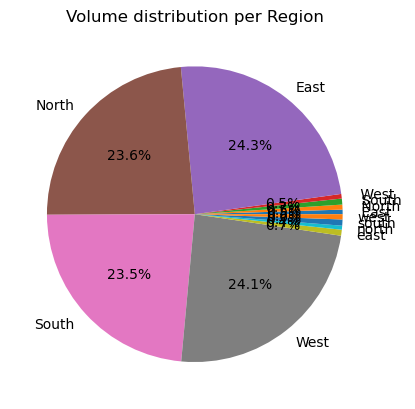

In [44]:
# Solution:
df.groupby('region')['transaction_amount'].sum().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title("Volume distribution per Region")
plt.show()

### 🔍 Scenario: Q44: Write code to plot a scatter plot of transaction_amount vs account_age_months.
- **Objective:** Q44: Write code to plot a scatter plot of transaction_amount vs account_age_months.
- **Approach:** Apply built-in transformations and inspect output integrity.

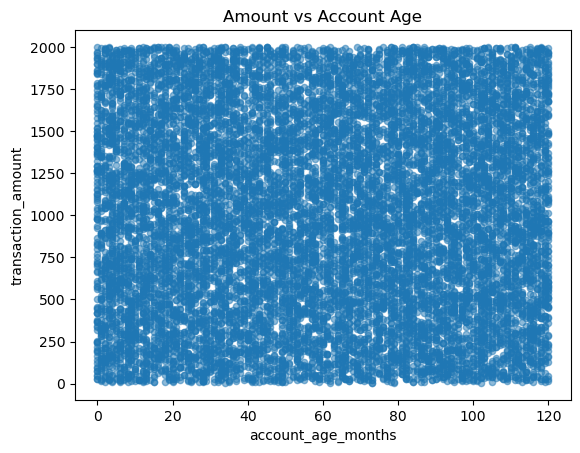

In [45]:
# Solution:
df.plot.scatter(x='account_age_months', y='transaction_amount', alpha=0.5)
plt.title("Amount vs Account Age")
plt.show()

### 🔍 Scenario: Q45: Write code to draw a bar chart of average transaction amounts across different regions.
- **Objective:** Q45: Write code to draw a bar chart of average transaction amounts across different regions.
- **Approach:** Apply built-in transformations and inspect output integrity.

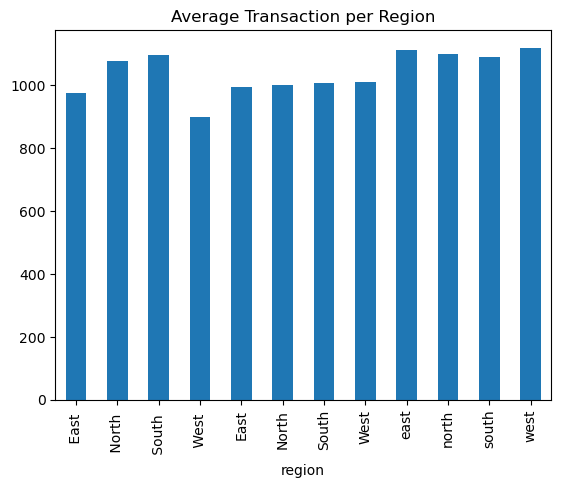

In [46]:
# Solution:
df.groupby('region')['transaction_amount'].mean().plot.bar()
plt.title("Average Transaction per Region")
plt.show()

### 🔍 Scenario: Q46: Write code to plot a histogram of transaction amounts with 20 bins.
- **Objective:** Q46: Write code to plot a histogram of transaction amounts with 20 bins.
- **Approach:** Apply built-in transformations and inspect output integrity.

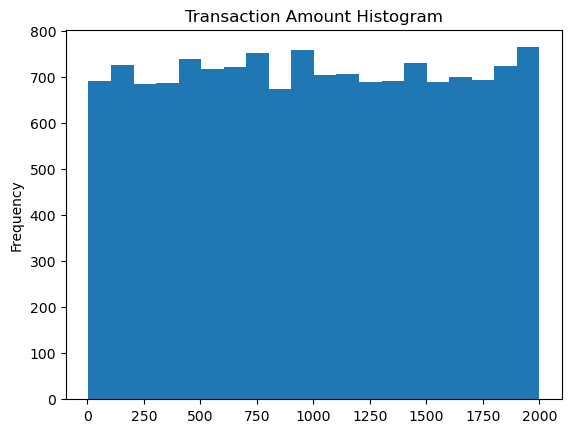

In [47]:
# Solution:
df['transaction_amount'].plot.hist(bins=20)
plt.title("Transaction Amount Histogram")
plt.show()

### 🔍 Scenario: Q47: Write code to draw a box plot of transaction amounts to detect extreme high-value outliers.
- **Objective:** Q47: Write code to draw a box plot of transaction amounts to detect extreme high-value outliers.
- **Approach:** Apply built-in transformations and inspect output integrity.

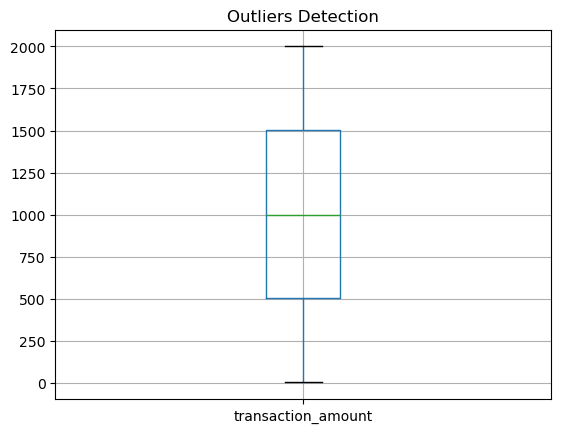

In [48]:
# Solution:
df.boxplot(column='transaction_amount')
plt.title("Outliers Detection")
plt.show()

### 🔍 Scenario: Q48: How do you convert the datatype of transaction_id to string and transaction_amount to float32 at once?
- **Objective:** Q48: How do you convert the datatype of transaction_id to string and transaction_amount to float32 at once?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [49]:
# Solution:
df_cast = df.astype({'transaction_id': 'str', 'transaction_amount': 'float32'})
print(df_cast.dtypes)

transaction_id         object
customer_id            object
merchant_id            object
transaction_amount    float32
card_type              object
transaction_status     object
device_type            object
account_age_months      uint8
transaction_date       object
region                 object
is_fraud                int64
amount_z_score        float64
dtype: object


### 🔍 Scenario: Q49: How do you merge transactions with a mock customer profile table containing customer signup dates?
- **Objective:** Q49: How do you merge transactions with a mock customer profile table containing customer signup dates?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [50]:
df_cust_profile = pd.DataFrame({
    'customer_id': df['customer_id'].dropna().unique(),
    'signup_year': np.random.choice([2022, 2023, 2024], size=len(df['customer_id'].dropna().unique()))
})
# Solution:
merged = pd.merge(df, df_cust_profile, on='customer_id', how='left')
print(merged[['customer_id', 'transaction_amount', 'signup_year']].head(5))

  customer_id  transaction_amount  signup_year
0      C55082              607.78         2022
1      C76616             1819.11         2022
2      C65296               64.08         2023
3      C42098             1025.73         2023
4      C97782              772.74         2023


### 🔍 Scenario: Q50: How do you save our cleaned transactions dataset to an Excel file under the sheet name 'Transactions_2026'?
- **Objective:** Q50: How do you save our cleaned transactions dataset to an Excel file under the sheet name 'Transactions_2026'?
- **Approach:** Apply built-in transformations and inspect output integrity.

In [51]:
# Solution:
# df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)
print("Mock: df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)")

Mock: df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)


### 🔍 Scenario: Q51: How do you perform a multi-table Fintech reconciliation across transactions, merchants, and chargeback disputes to calculate net settlement and flag regulatory non-compliance?
- **Objective:** Q51: How do you perform a multi-table Fintech reconciliation across transactions, merchants, and chargeback disputes to calculate net settlement and flag regulatory non-compliance?
- **Approach:** 

In [52]:
# Q51 Multi-Table Reconciliation Implementation
data_dir = 'data' if os.path.exists('data/merchants.csv') else '../data'
df_cust = pd.read_csv(f'{data_dir}/customers.csv')
df_merch = pd.read_csv(f'{data_dir}/merchants.csv')
df_disp = pd.read_csv(f'{data_dir}/disputes.csv')

# Step 1: Clean transactions & compute fees
tx_valid = df.dropna(subset=['transaction_amount']).copy()
tx_valid = tx_valid.merge(df_merch[['merchant_id', 'merchant_name', 'interchange_fee_pct']], on='merchant_id', how='left')
tx_valid['fee'] = tx_valid['transaction_amount'] * tx_valid['interchange_fee_pct']

# Step 2: Merchant aggregation
merch_summary = tx_valid.groupby(['merchant_id', 'merchant_name']).agg(
    tx_count=('transaction_id', 'count'),
    gross_volume=('transaction_amount', 'sum'),
    total_fee=('fee', 'sum')
).reset_index()

# Step 3: Disputes aggregation
disp_summary = df_disp.groupby('merchant_id').agg(
    dispute_count=('dispute_id', 'count'),
    chargeback_loss=('disputed_amount', lambda amt: amt[df_disp.loc[amt.index, 'dispute_status'] == 'Won - Customer'].sum()),
    chargeback_fees=('chargeback_fee_usd', 'sum')
).reset_index()

# Step 4: Final reconciliation
reconciliation = (
    merch_summary
    .merge(disp_summary, on='merchant_id', how='left')
    .fillna({'dispute_count': 0, 'chargeback_loss': 0, 'chargeback_fees': 0})
)

reconciliation['dispute_rate_pct'] = (reconciliation['dispute_count'] / reconciliation['tx_count']) * 100
reconciliation['net_payout'] = reconciliation['gross_volume'] - reconciliation['total_fee'] - reconciliation['chargeback_loss'] - reconciliation['chargeback_fees']
reconciliation['vamp_flag'] = np.where(reconciliation['dispute_rate_pct'] > 1.0, 'FLAGGED (>1%)', 'COMPLIANT')

print("Fintech Merchant Reconciliation & Compliance:")
print(reconciliation[['merchant_id', 'merchant_name', 'tx_count', 'gross_volume', 'dispute_rate_pct', 'vamp_flag', 'net_payout']].head(10).round(2))


Fintech Merchant Reconciliation & Compliance:
  merchant_id       merchant_name  tx_count  gross_volume  dispute_rate_pct  \
0       M1025         Pulse Cloud        24      26365.99             54.17   
1       M1086     Hyper Solutions        33      37092.24             48.48   
2       M1100       Velocity Mart        27      22293.18             44.44   
3       M1125          Prime Tech        27      27886.69             44.44   
4       M1126     SilverLine Tech        30      29945.78             36.67   
5       M1266        Hyper Retail        25      25205.39             44.00   
6       M1269  Vanguard Solutions        23      24485.62             56.52   
7       M1298          Apex Foods        34      30785.31             35.29   
8       M1307        Alpha Retail        40      43293.68             65.00   
9       M1311        Zenith Cloud        26      24490.32             38.46   

       vamp_flag  net_payout  
0  FLAGGED (>1%)    25598.96  
1  FLAGGED (>1%)    33